# Violent Crime Capstone

This notebook reruns the methodology using the "capstone_count_rate_density.csv"


## 1. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

BASE_DIR = Path.cwd()
CLEAN_DATA = BASE_DIR / 'cleaned_data'
OUTPUTS = BASE_DIR / 'outputs'

CLEAN_DATA.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)


## 2. Load Original and Updated Datasets

In [3]:
import pandas as pd

old_df = pd.read_csv("violent_crime_final_dataset.csv")
old_df.head()

,state,metropolitan_nonmetropolitan,county,violent_crime,murder_and_nonnegligent_manslaughter,rape,robbery,aggravated_assault,property_crime,burglary,larceny_theft,motor_vehicle_theft,arson,year,state_abbr,county_clean,fips,county_name,labor_force,employed,unemployed,unemployment_rate,median_household_income,poverty_rate,bachelors_or_higher_pct
0,ALABAMA,Metropolitan County,Autauga,54,1,7,0,46,221,46,143,32,1,2024,AL,AUTAUGA,1001,"Autauga County, AL","28,467.000","27,702.000",765.000,2.700,"72,481.000",11.300,29.100
1,ALABAMA,Metropolitan County,Baldwin,137,0,4,0,133,170,23,142,5,2,2024,AL,BALDWIN,1003,"Baldwin County, AL","116,653.000","113,448.000","3,205.000",2.700,"78,775.000",10.100,33.700
2,ALABAMA,Metropolitan County,Bibb,34,0,5,0,29,78,26,43,9,0,2024,AL,BIBB,1007,"Bibb County, AL","8,710.000","8,446.000",264.000,3.000,"52,541.000",22.500,11.700
3,ALABAMA,Metropolitan County,Blount,82,1,18,2,61,298,66,180,52,2,2024,AL,BLOUNT,1009,"Blount County, AL","26,922.000","26,204.000",718.000,2.700,"64,190.000",12.900,15.800
4,ALABAMA,Metropolitan County,Calhoun,238,2,5,0,231,192,48,144,0,8,2024,AL,CALHOUN,1015,"Calhoun County, AL","49,605.000","47,995.000","1,610.000",3.200,"55,029.000",17.900,20.600


In [4]:
old_df.dtypes

state                                       str
metropolitan_nonmetropolitan                str
county                                      str
violent_crime                             int64
murder_and_nonnegligent_manslaughter      int64
rape                                      int64
robbery                                   int64
aggravated_assault                        int64
property_crime                            int64
burglary                                  int64
larceny_theft                             int64
motor_vehicle_theft                       int64
arson                                     int64
year                                      int64
state_abbr                                  str
county_clean                                str
fips                                      int64
county_name                                 str
labor_force                             float64
employed                                float64
unemployed                              

In [5]:
import pandas as pd

df = pd.read_csv("capstone_count_rate_density.csv")
df.head()


,state,metropolitan_nonmetropolitan,county,violent_crime_count,murder_and_nonnegligent_manslaughter_count,rape_count,robbery_count,aggravated_assault_count,property_crime,burglary,larceny_theft,motor_vehicle_theft,arson,year,state.1,county_clean,fips,county.1,labor_force,employed,unemployed,unemployment_pct,median_income,poverty_pct,bachelors_or_higher_pct,population,violent_crime_rate_per_100k,murder_and_nonnegligent_manslaughter_rate,rape_rate,robbery_rate,aggravated_assault_rate,county_state,poverty_bin,unemployment_bin,education_bin,GEOID,ALAND,land_area_sq_miles,population_density
0,ALABAMA,Metropolitan County,Autauga,54,1,7,0,46,221,46,143,32,1,2024,AL,AUTAUGA,1001,"Autauga County, AL","28,467.000","27,702.000",765.000,2.700,"72,481.000",11.300,29.100,59947,90.080,1.668,11.677,0.000,76.734,"Autauga, ALABAMA",Medium-Low,Low,Medium-High,1001,1539631459,594.455,100.844
1,ALABAMA,Metropolitan County,Baldwin,137,0,4,0,133,170,23,142,5,2,2024,AL,BALDWIN,1003,"Baldwin County, AL","116,653.000","113,448.000","3,205.000",2.700,"78,775.000",10.100,33.700,246989,55.468,0.000,1.620,0.000,53.849,"Baldwin, ALABAMA",Low,Low,High,1003,4117781416,"1,589.884",155.350
2,ALABAMA,Metropolitan County,Bibb,34,0,5,0,29,78,26,43,9,0,2024,AL,BIBB,1007,"Bibb County, AL","8,710.000","8,446.000",264.000,3.000,"52,541.000",22.500,11.700,22130,153.638,0.000,22.594,0.000,131.044,"Bibb, ALABAMA",High,Low,Low,1007,1612188713,622.470,35.552
3,ALABAMA,Metropolitan County,Blount,82,1,18,2,61,298,66,180,52,2,2024,AL,BLOUNT,1009,"Blount County, AL","26,922.000","26,204.000",718.000,2.700,"64,190.000",12.900,15.800,59518,137.773,1.680,30.243,3.360,102.490,"Blount, ALABAMA",Medium-Low,Low,Low,1009,1670259099,644.891,92.292
4,ALABAMA,Metropolitan County,Calhoun,238,2,5,0,231,192,48,144,0,8,2024,AL,CALHOUN,1015,"Calhoun County, AL","49,605.000","47,995.000","1,610.000",3.200,"55,029.000",17.900,20.600,116090,205.013,1.723,4.307,0.000,198.984,"Calhoun, ALABAMA",High,Low,Medium-Low,1015,1569256885,605.893,191.601


In [6]:
label_map = {
    "violent_crime_count": "Violent Crime Count",
    "murder_and_nonnegligent_manslaughter_count": "Murder (Nonnegligent) Count",
    "rape_count": "Rape Count",
    "robbery_count": "Robbery Count",
    "aggravated_assault_count": "Aggravated Assault Count",

    "violent_crime_rate_per_100k": "Violent Crime Rate (per 100,000)",
    "murder_and_nonnegligent_manslaughter_rate": "Murder (Nonnegligent Manslaughter) Rate",
    "rape_rate": "Rape Rate",
    "robbery_rate": "Robbery Rate",
    "aggravated_assault_rate": "Aggravated Assault Rate",

    "unemployment_pct": "Unemployment Rate (%)",
    "poverty_pct": "Poverty Rate (%)",
    "bachelors_or_higher_pct": "Bachelor's Degree (%)",

    "median_income": "Median Household Income",

    "county": "County",
    "state": "State",
    "county_state": "County State",
    "population_density": "Population Density"
}

In [7]:
df.dtypes

state                                             str
metropolitan_nonmetropolitan                      str
county                                            str
violent_crime_count                             int64
murder_and_nonnegligent_manslaughter_count      int64
rape_count                                      int64
robbery_count                                   int64
aggravated_assault_count                        int64
property_crime                                  int64
burglary                                        int64
larceny_theft                                   int64
motor_vehicle_theft                             int64
arson                                           int64
year                                            int64
state.1                                           str
county_clean                                      str
fips                                            int64
county.1                                          str
labor_force                 

## 3. Modeling: Linear Regression and Random Forest

We use two regression models to predict county-level violent crime counts from socioeconomic factors.  
Linear regression serves as a baseline, interpretable model that shows the direction and size of relationships between predictors and violent crime.  
Random forest regression is used as a more flexible model that can capture nonlinear relationships and interactions between predictors.  
Comparing both models allows us to balance interpretability and predictive performance while also identifying which socioeconomic variables are the strongest predictors of violent crime.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [9]:
df['income_k'] = df['median_income'] / 1000

In [10]:
df.dtypes

state                                             str
metropolitan_nonmetropolitan                      str
county                                            str
violent_crime_count                             int64
murder_and_nonnegligent_manslaughter_count      int64
rape_count                                      int64
robbery_count                                   int64
aggravated_assault_count                        int64
property_crime                                  int64
burglary                                        int64
larceny_theft                                   int64
motor_vehicle_theft                             int64
arson                                           int64
year                                            int64
state.1                                           str
county_clean                                      str
fips                                            int64
county.1                                          str
labor_force                 

In [11]:
# log-transform target
# compresses large values and reduces skew
df['log_violent_crime_rate_per_100k'] = np.log1p(df['violent_crime_rate_per_100k'])

# make dummy variables
df = pd.get_dummies(
    df,
    columns=['metropolitan_nonmetropolitan', 'state'],
    drop_first=True,
    dtype=int
)

base_features = [
    'unemployment_pct',
    'income_k',
    'poverty_pct',
    'bachelors_or_higher_pct'
]

# only keep numeric dummy columns, not raw text columns like state_abbr
dummy_features = [
    c for c in df.columns
    if (
        c.startswith('metropolitan_nonmetropolitan_') or c.startswith('state_')
    ) and pd.api.types.is_numeric_dtype(df[c])
]

features = base_features + dummy_features
target = 'log_violent_crime_rate_per_100k'

df = df.dropna(subset=features + [target]).copy()

X = df[features]
y = df[target]

print("Any object columns in X?")
print(X.select_dtypes(include='object').columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Number of features:", len(features))

Any object columns in X?
[]
Training shape: (1486, 48)
Testing shape: (372, 48)
Number of features: 48


## 3a. Linear Regression

Results

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results")
print("R^2:", round(lr_r2, 4))
print("RMSE:", round(lr_rmse, 4))
print("MAE:", round(lr_mae, 4))

Linear Regression Results
R^2: 0.3427
RMSE: 0.8567
MAE: 0.6246


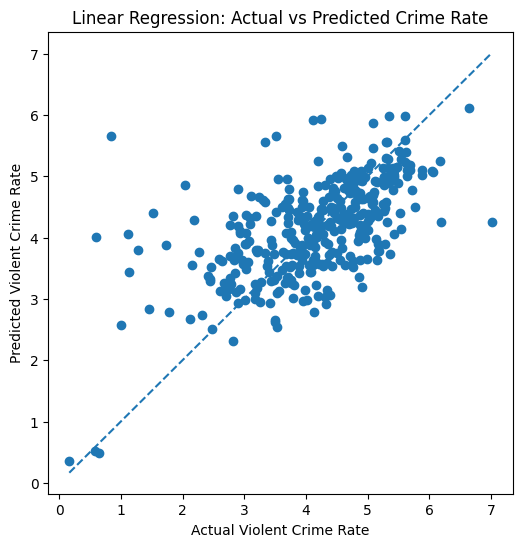

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual Violent Crime Rate")
plt.ylabel("Predicted Violent Crime Rate")
plt.title("Linear Regression: Actual vs Predicted Crime Rate")
plt.show()

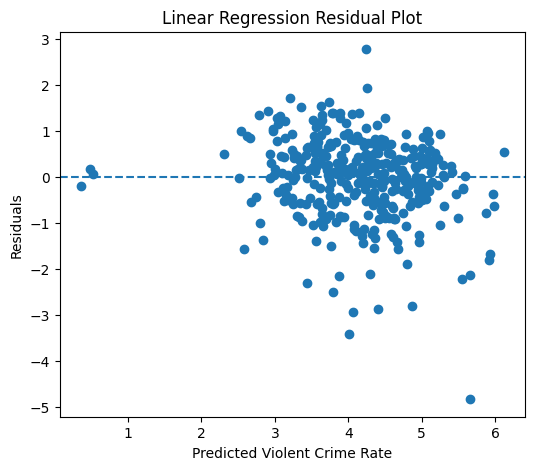

In [17]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(6, 5))
plt.scatter(y_pred_lr, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Violent Crime Rate")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.show()

Strongest Coefficints - Without States

In [23]:
coef_df[~coef_df['Feature'].str.startswith('state_')]

,Feature,Coefficient
4,metropolitan_nonmetropolitan_Nonmetropolitan C...,0.097
0,unemployment_pct,0.082
3,bachelors_or_higher_pct,-0.029
2,poverty_pct,-0.015
1,income_k,0.002


Strongest Coefficients - With States

In [13]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df

,Feature,Coefficient
36,state_PENNSYLVANIA,-3.698
28,state_NEW JERSEY,-3.279
27,state_NEW HAMPSHIRE,-2.709
37,state_SOUTH CAROLINA,1.426
16,state_KENTUCKY,-1.399
42,state_VERMONT,-1.163
30,state_NEW YORK,-1.068
18,state_MAINE,-1.021
25,state_NEBRASKA,-1.018
17,state_LOUISIANA,0.927


## 3b. Random Forest

Results

In [14]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results")
print("R^2:", round(rf_r2, 4))
print("RMSE:", round(rf_rmse, 4))
print("MAE:", round(rf_mae, 4))

Random Forest Results
R^2: 0.2881
RMSE: 0.8916
MAE: 0.6602


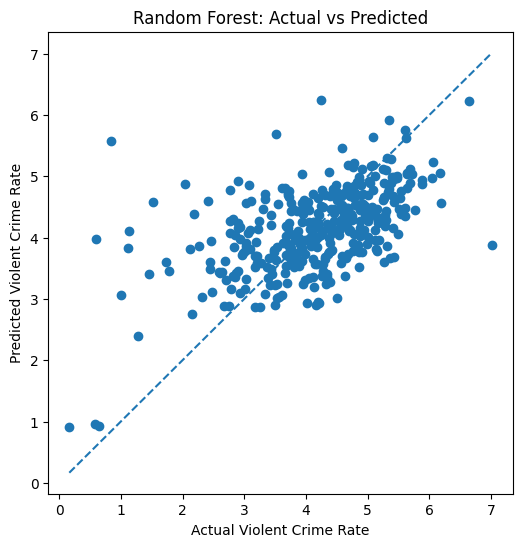

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual Violent Crime Rate")
plt.ylabel("Predicted Violent Crime Rate")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

Importance - Without States

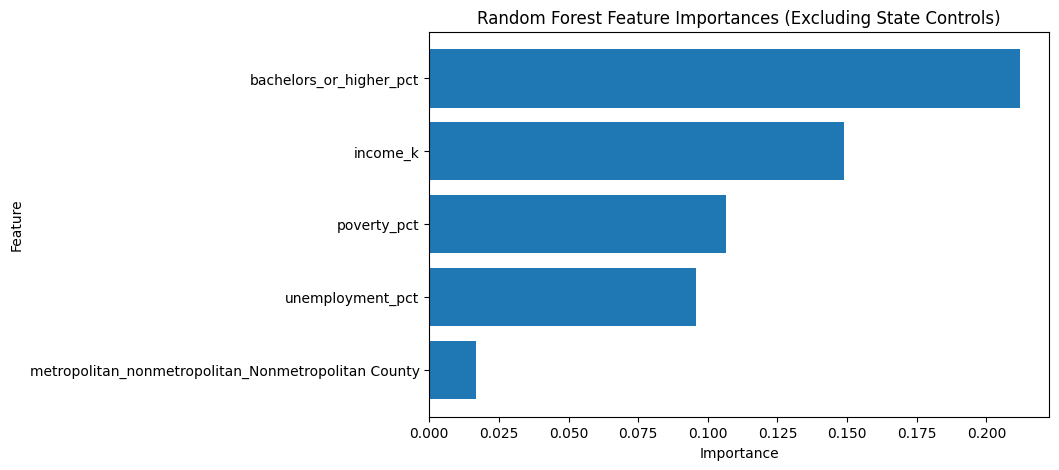

In [25]:
rf_importance_filtered = rf_importance[
    ~rf_importance['Feature'].str.startswith('state_')
].copy()

rf_importance_filtered

top_rf = rf_importance_filtered.sort_values('Importance')

plt.figure(figsize=(8,5))
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances (Excluding State Controls)")
plt.show()

Importance - With States

In [15]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importance

,Feature,Importance
3,bachelors_or_higher_pct,0.212
1,income_k,0.149
2,poverty_pct,0.107
0,unemployment_pct,0.096
16,state_KENTUCKY,0.071
36,state_PENNSYLVANIA,0.030
37,state_SOUTH CAROLINA,0.028
28,state_NEW JERSEY,0.028
30,state_NEW YORK,0.021
27,state_NEW HAMPSHIRE,0.021


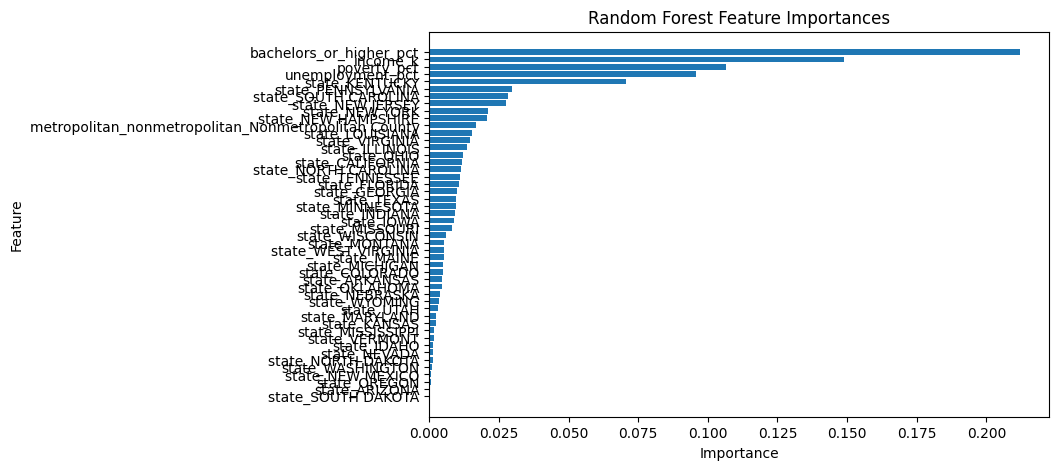

In [19]:
top_rf = rf_importance.sort_values('Importance')

plt.figure(figsize=(8, 5))
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.show()

In [24]:
rf_importance[~rf_importance['Feature'].str.startswith('state_')]

,Feature,Importance
3,bachelors_or_higher_pct,0.212
1,income_k,0.149
2,poverty_pct,0.107
0,unemployment_pct,0.096
4,metropolitan_nonmetropolitan_Nonmetropolitan C...,0.017


## 4. Comparison

In [20]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R^2': [lr_r2, rf_r2],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae]
})

results_df

,Model,R^2,RMSE,MAE
0,Linear Regression,0.343,0.857,0.625
1,Random Forest,0.288,0.892,0.660
